In [18]:
import numpy as np

dataset_file = np.load('data_model/files_train_antennas_still,scroll,flip,type.txt', allow_pickle=True)

print(dataset_file)

['/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/0.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/1.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/2.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/3.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/4.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/5.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/6.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/7.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/8.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/9.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/10.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/11.txt', '/home/drone/BTP/data_model/train_antennas_still,scroll,flip,type/12.txt', '/home/drone/BTP/data_model/train_

In [17]:
import doppler_create_complete_test_from_labels as dcc

doppler_map, fs, hop, win_len = dcc.load_doppler_file('doppler_traces/scroll/4_doppler.npz')
# print(doppler_map.shape)
total_rows, _freq_bins = doppler_map.shape
start_i, end_i = dcc.stft_row_range(25, 2, fs, win_len, hop)
end_i = min(end_i, total_rows)
block = doppler_map[start_i:end_i, :]  # (T, F)
sample = np.transpose(block, (1, 0))[np.newaxis, :, :]
csi_complete = sample.astype(np.float32, copy=False)
# print(csi_complete)

for i in range(0, 141):
    df = np.load('model_data/train_antennas_Still,Scrolling,Flipping,Typing/'+str(i)+'.txt', allow_pickle=True)
    if (df == csi_complete).all():
        print(f"match found! train/{i}.txt")

for i in range(0, 48):
    df = np.load('model_data/test_antennas_Still,Scrolling,Flipping,Typing/'+str(i)+'.txt', allow_pickle=True)
    if (df == csi_complete).all():
        print(f"match found! test/{i}.txt")

for i in range(0, 47):
    df = np.load('model_data/val_antennas_Still,Scrolling,Flipping,Typing/'+str(i)+'.txt', allow_pickle=True)
    if (df == csi_complete).all():
        print(f"match found! val/{i}.txt")

match found! test/15.txt


In [19]:
file = np.load('test_model_data/num_windows_complete_antennas_Still,Scrolling,Flipping,Typing.txt', allow_pickle=True)
print(file)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [33]:
import matplotlib.pyplot as plt

def plot_doppler_spectrogram(start_idx, csi_d_map, window_size, freqs=None):
    """
    start_idx: starting frame index
    csi_d_map: (frames, freq)
    window_size: number of frames to stack
    freqs: optional frequency axis
    """

    csi_d_map = csi_d_map.T
    frames, F = csi_d_map.shape
    end_idx = start_idx + window_size
    if end_idx > frames:
        raise ValueError("Window exceeds available frames")

    window = csi_d_map[start_idx:end_idx]   # (W, F)

    spec_db = np.log10(window + 1e-9)

    plt.figure(figsize=(8, 5))

    freq_const = 500
    offset = 0
    x_vals = np.array([(i * 10 + offset) / freq_const for i in range(window_size)])

    if freqs is not None:
        plt.imshow(
            spec_db.T,
            aspect='auto',
            origin='lower',
            extent=[x_vals[0], x_vals[-1], freqs[0], freqs[-1]],
            cmap='jet'
        )
        plt.ylabel("Frequency (Hz)")
    else:
        plt.imshow(
            spec_db.T,
            aspect='auto',
            origin='lower',
            extent=[x_vals[0], x_vals[-1], 0, F],
            cmap='jet'
        )
        plt.ylabel("Frequency bin")

    plt.xlabel("Time (s)")
    plt.title(f"Doppler Spectrogram (Doppler vector {start_idx} → {end_idx})")

    plt.colorbar(label="Magnitude (dB)")
    plt.tight_layout()
    plt.show()

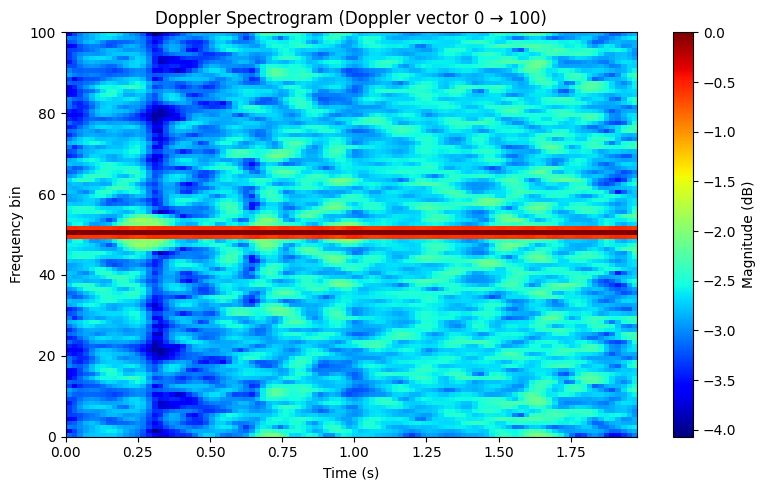

Activity:  still


In [36]:
i = 26

file = np.load(f'data_model/train_antennas_still,scroll,flip,type/{i}.txt', allow_pickle=True)
file = np.squeeze(file)
plot_doppler_spectrogram(0, file, 100)

labels = np.load(f'data_model/labels_train_antennas_still,scroll,flip,type.txt', allow_pickle=True)
label = labels[i]
LABELS = ['still', 'scroll', 'flip', 'type']
print("Activity: ", LABELS[label])

In [42]:
from collections import Counter

train_labels = np.load(f'data_model/labels_train_antennas_still,scroll,flip,type.txt', allow_pickle=True)
val_labels = np.load(f'data_model/labels_val_antennas_still,scroll,flip,type.txt', allow_pickle=True)
test_labels = np.load(f'data_model/labels_test_antennas_still,scroll,flip,type.txt', allow_pickle=True)

freq = Counter(train_labels + val_labels + test_labels)
print(freq)

Counter({0: 1872, 1: 1560, 2: 1560, 3: 1560})
